In [ ]:
# ============================================
# Blockwise permutation + Areal GP + VI module
# Using meuse_obs.zip (geopandas) & elev as X
# ============================================

from math import pi
import os
from typing import Dict, Any, Sequence

import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm

import pandas as pd
import geopandas as gpd  # <--- NEW

from GPModel import GPModel
from GPArealModel import GPArealModel
from revised_VIGP_Unlinked import VIGP_Unlinked
from utils import round_to_perm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _to_tensor(x, dtype=torch.float32):
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=dtype)
    return torch.as_tensor(x, device=device, dtype=dtype)


# ---------------------------------------------------------
# STEP 2 helper: construct blockwise permutation at data level
# ---------------------------------------------------------

def make_blockwise_permuted_data(
    coords,
    X,
    Y,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
) -> Dict[str, torch.Tensor]:
    """
    Prepare original (restricted) and blockwise-permuted data.

    Inputs
    ------
    coords : array-like (N, d)
    X      : array-like (N,) or (N, 1)
    Y      : array-like (N,)
    n_blocks, n_locations : define N_use = n_blocks * n_locations
    seed : for reproducible permutations

    Returns a dict with:
        coords_orig, X_orig, Y_orig   : restricted, sorted (unpermuted)
        coords_perm, X_perm, Y_perm   : permuted inside blocks
        region_assignments            : (N_use,) with values 0,...,B-1
        perm_matrix_x, perm_matrix_s  : (N_use, N_use) block-diagonal perms
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords = _to_tensor(coords)
    Y = _to_tensor(Y).view(-1)  # (N,)
    X = _to_tensor(X)

    if X.ndim == 1:
        X = X.unsqueeze(1)  # (N, 1)

    N_total = coords.shape[0]
    N_use = n_blocks * n_locations
    if N_total < N_use:
        raise ValueError(f"Not enough locations: N={N_total}, required N_use={N_use}.")

    # Sort by first coordinate (x), then restrict to N_use
    sort_idx = torch.argsort(coords[:, 0])
    sort_idx = sort_idx[:N_use]

    coords_orig = coords[sort_idx].contiguous()  # (N_use, d)
    X_orig = X[sort_idx].contiguous()            # (N_use, 1)
    Y_orig = Y[sort_idx].contiguous()            # (N_use,)

    N = N_use

    # Region assignments: fixed blocks
    region_assignments = torch.zeros(N, dtype=torch.long, device=device)
    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations
        region_assignments[start:end] = b

    # Blockwise permutation matrices
    #   - perm_matrix_x: permutes X,Y jointly within block
    #   - perm_matrix_s: independent perm for coordinates
    perm_x = torch.randperm(n_locations)
    perm_s = torch.randperm(n_locations)
    # Convert perm_s into a permutation matrix
    perm_matrix_s = torch.zeros(n_locations, n_locations, dtype=torch.float32, device=device)
    perm_matrix_s[torch.arange(n_locations), perm_s] = 1

    # Convert perm_x into a permutation matrix
    perm_matrix_x = torch.zeros(n_locations, n_locations, dtype=torch.float32, device=device)
    perm_matrix_x[torch.arange(n_locations), perm_x] = 1
    
    unique_regions = torch.unique(region_assignments)
    X_perm = torch.zeros_like(X_orig)
    coords_perm = torch.zeros_like(coords_orig)
    for i, region in enumerate(unique_regions):
            # Get indices for the current region
            indices = torch.where(region_assignments == region)[0]
            
            # Assign the shuffled values back
            X_perm[indices] = X_orig[indices[perm_x]]
            coords_perm[indices] = coords_orig[indices[perm_s]]

    
    # Apply permutations
    Y_perm = Y_orig

    return {
        "coords_orig": coords_orig,
        "X_orig": X_orig,
        "Y_orig": Y_orig,
        "coords_perm": coords_perm,
        "X_perm": X_perm,
        "Y_perm": Y_perm,
        "region_assignments": region_assignments,
        "perm_matrix_x": perm_matrix_x,
        "perm_matrix_s": perm_matrix_s,
    }


# ---------------------------------------------------------
# STEP 3a: Areal GP ONLY (disentangled)
# ---------------------------------------------------------

def run_areal_gp(
    coords_perm: torch.Tensor,
    X_perm: torch.Tensor,
    Y_perm: torch.Tensor,
    region_assignments: torch.Tensor,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
    max_iter: int = 200,
    tol: float = 1e-4,
    W: int = 10,
) -> Dict[str, Any]:
    """
    Run GPArealModel (areal GP) on block-averaged data,
    using permuted coordinates and block structure.
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords_perm = _to_tensor(coords_perm)
    Y_perm = _to_tensor(Y_perm).view(-1)
    X_perm = _to_tensor(X_perm)

    if X_perm.ndim == 1:
        X_perm = X_perm.unsqueeze(1)
    p = X_perm.shape[1]
    if p != 1:
        raise ValueError(f"GPArealModel wrapper assumes scalar X (p=1), got p={p}.")

    region_assignments = region_assignments.to(device=device, dtype=torch.long)

    N = coords_perm.shape[0]
    assert N == n_blocks * n_locations, "N must equal n_blocks * n_locations."

    # Block averages of X and Y
    ybar = torch.zeros(n_blocks, device=device)
    xbar = torch.zeros(n_blocks, p, device=device)

    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations
        idx = torch.arange(start, end, device=device)
        ybar[b] = Y_perm[idx].mean()
        xbar[b] = X_perm[idx].mean(dim=0)

    
    gpa = GPArealModel().to(device)
    opt = optim.AdamW(gpa.parameters(), lr=0.01, weight_decay=0.01)

    gpa_loss_history = []

    for it in tqdm(range(max_iter), desc="Train GPArealModel"):
        opt.zero_grad(set_to_none=True)
        loss = gpa(coords_perm, region_assignments, xbar, ybar)
        loss.backward()
        opt.step()

        cur = float(loss.detach().item())
        gpa_loss_history.append(cur)

        if it > W:
            recent = gpa_loss_history[-W:]
            rel_range = (max(recent) - min(recent)) / (abs(recent[-1]) + 1e-12)
            if rel_range < tol:
                print(f"[Stop GPA] plateau over last {W} iters at it={it}, loss={cur:.6f}")
                break


    return {
        "loss_history": gpa_loss_history,
        "nu": float(gpa.nu.item()),
        "phi": float(np.exp(gpa.logphi.item())),
        "sigmasq": float(np.exp(gpa.logsigmasq.item())),
        "tausq": float(np.exp(gpa.logtausq.item())),
        "beta": gpa.beta.detach().cpu().numpy(),
    }


# ---------------------------------------------------------
# STEP 3b: VI for Unlinked GP ONLY (disentangled)
# ---------------------------------------------------------

def run_vi_unlinked(
    coords_perm: torch.Tensor,
    X_perm: torch.Tensor,
    Y_perm: torch.Tensor,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
    niter_VI: int = 100,
    phi_prior_ub: float = 0.5,
    phi_prior_lb: float = 0.0,
    lr_piS=0.01,
    lr_piX=0.01,
    VX_ub: float = 0.5,
    VS_ub: float = 0.5,
    pi_X_true = None,
    pi_S_true = None
) -> Dict[str, Any]:
    """
    Run VIGP_Unlinked (VI for unlinked GP) on blockwise permuted X,Y,S.

    Returns a dict with VI outputs for each tau:
        {
          "by_tau": { tau_value: vi_out, ... },
          "taus": [...],
          "prior_parameters": {...}
        }
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords_perm = _to_tensor(coords_perm)
    Y_perm = _to_tensor(Y_perm).view(-1)  # (N,)
    X_perm = _to_tensor(X_perm)

    if X_perm.ndim == 1:
        X_perm = X_perm.unsqueeze(1)
    p = X_perm.shape[1]
    if p != 1:
        raise ValueError(f"VI wrapper assumes scalar X (p=1), got p={p}.")



    N = coords_perm.shape[0]
    assert N == n_blocks * n_locations, "N must equal n_blocks * n_locations."

    # Distances from permuted coordinates
    Dist = torch.cdist(coords_perm, coords_perm, p=2)
    Dist = (Dist + Dist.T) / 2.0

    # Block-shaped tensors for VI
    X_blocks = X_perm.view(n_blocks, n_locations)  # (B, n_i)
    Y_blocks = Y_perm.view(n_blocks, n_locations)  # (B, n_i)

    n_steps = 50
    n_phi_samples = 200
    n_piX_sample = 50
    n_piS_sample = 50

    prior_parameters = {
        "a1": 0.1,
        "b1": 0.1,
        "a2": 0.1,
        "b2": 0.1,
        "eta_X_sq": 0.1,
        "eta_S_sq": 0.1,
        "mu_beta": 0.0,
        "sigmasq_beta": 100.0,
        "phi_prior_lb": phi_prior_lb,
        "phi_prior_ub": phi_prior_ub,
    }


    vi_results_by_tau: Dict[float, Any] = {}

    tau=0.9
    results_VI = VIGP_Unlinked(
        n_iter=niter_VI,
        n_blocks=n_blocks,
        n_locations=n_locations,
        X=X_blocks, Y=Y_blocks,
        Dist=Dist,
        n_steps=n_steps,
        n_phi_samples=n_phi_samples,
        n_piX_sample=n_piX_sample,
        tau_X=tau, tau_S=tau,
        n_piS_sample=n_piS_sample,
        seed=521,
        fix_piX=False, fix_piS=False,
        fix_mu_lambda_beta=False,
        fix_sigmasq_lambda_beta=False,
        fix_lambda_b1=False,
        lambda_b1_fixed=((n_blocks * n_locations) * 0.5 + 0.1) * 5,
        fix_lambda_b2=False,
        M_X_star_fixed=pi_X_true.T,
        M_S_star_fixed=pi_X_true.T,
        V_X_star_fixed=torch.eye(n_locations, n_locations, device=device),
        V_S_star_fixed=torch.eye(n_locations, n_locations, device=device),
        phi_init=0.1,
        mean_Rphi_inv_fixed=torch.linalg.inv(torch.exp(-4 * Dist)),
        fix_mean_Rphi_inv=False,
        pi_X_true=pi_X_true,
        pi_S_true=pi_S_true,
        VX_ub=VX_ub, VS_ub=VS_ub,
        lr_piS=lr_piS, lr_piX=lr_piX,
        prior_parameters=prior_parameters,
        anneal_every=20, use_global_tau_anneal= True, elbo_W= 5, tol=0.1, return_mu_W_Sigma=True,
    )

    return {"results": results_VI, 
        "prior_parameters": prior_parameters,
    }


# ============================================================
# Demo: FULL PIPELINE on meuse_obs.zip
# ============================================================


# __file__ is not defined in interactive environments (e.g., Jupyter notebooks).
# Fall back to the current working directory when needed.
try:
    base_dir = os.path.dirname(__file__)
except NameError:
    base_dir = os.getcwd()

MEUSE_OBS_PATH = os.path.abspath(os.path.join(
    base_dir,
    "..",
    "data", "data_analysis",
    "meuse_obs.zip",
))

meuse_obs = gpd.read_file(MEUSE_OBS_PATH)

# coords from geometry (x, y)
coords_meuse = np.column_stack(
    [meuse_obs.geometry.x.to_numpy(), meuse_obs.geometry.y.to_numpy()]
)

# response: log1p(zinc)
Y_meuse = np.log1p(meuse_obs["zinc"].to_numpy())

# scalar covariate: elevation
# (column name in this dataset is 'elev'; if it's 'elevation' on your side, change here)
#X_meuse = np.sqrt(meuse_obs["dist"].to_numpy())
X_meuse = meuse_obs["elev"].to_numpy()

# center covariate and response to zero mean
X_meuse_mean = X_meuse.mean()
Y_meuse_mean = Y_meuse.mean()

X_meuse = X_meuse - X_meuse_mean
Y_meuse = Y_meuse - Y_meuse_mean

print(f"Centered X_meuse mean: {X_meuse.mean():.6f}, Y_meuse mean: {Y_meuse.mean():.6f}")

N_meuse = coords_meuse.shape[0]
print(f"Loaded meuse_obs: N = {N_meuse}")

# Rescale coordinates for numerical stability (e.g. to km)
coords_center = coords_meuse.mean(axis=0)
coords_scaled = (coords_meuse) / 1000.0  # now roughly in km
# Normalize coordinates to [0, 1] range
coords_min = coords_meuse.min(axis=0)
coords_max = coords_meuse.max(axis=0)
coords_scaled = (coords_meuse - coords_min) / (coords_max - coords_min)

print(f"Coordinates normalized to [0, 1]: min={coords_scaled.min():.6f}, max={coords_scaled.max():.6f}")


Centered X_meuse mean: -0.000000, Y_meuse mean: 0.000000
Loaded meuse_obs: N = 155
Coordinates normalized to [0, 1]: min=0.000000, max=1.000000


In [2]:
coords_perm_data = make_blockwise_permuted_data(
    coords=coords_scaled,
    X=X_meuse,
    Y=Y_meuse,
    n_blocks=31,
    n_locations=5,
    seed=2029,
)
coords_perm = coords_perm_data["coords_perm"]
X_perm = coords_perm_data["X_perm"]
Y_perm = coords_perm_data["Y_perm"]
region_assignments = coords_perm_data["region_assignments"]
perm_matrix_x = coords_perm_data["perm_matrix_x"]
perm_matrix_s = coords_perm_data["perm_matrix_s"]


In [3]:

# -----------------------------
# STEP 3a: Areal GP on permuted data
# -----------------------------
areal_results = run_areal_gp(
    coords_perm=coords_perm,
    X_perm=X_perm,
    Y_perm=Y_perm,
    region_assignments=region_assignments,
    n_blocks=31,
    n_locations=5,
    seed=2030,
    max_iter=20000
)


Train GPArealModel:   0%|          | 0/20000 [00:00<?, ?it/s]/Users/debangandey/Documents/GitHub/SpatialReg-Unlinked/src/GPArealModel.py:25: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729646995093/work/aten/src/ATen/native/TensorShape.cpp:3687.)
  quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
Train GPArealModel:   4%|▍         | 872/20000 [00:00<00:10, 1765.85it/s]

[Stop GPA] plateau over last 10 iters at it=872, loss=-30.140671


In [4]:
areal_results

{'loss_history': [-12.514688491821289,
  -12.710677146911621,
  -12.905391693115234,
  -13.098751068115234,
  -13.29066276550293,
  -13.481058120727539,
  -13.669839859008789,
  -13.856934547424316,
  -14.042242050170898,
  -14.225690841674805,
  -14.407190322875977,
  -14.586660385131836,
  -14.764009475708008,
  -14.93917179107666,
  -15.112065315246582,
  -15.282614707946777,
  -15.450759887695312,
  -15.616430282592773,
  -15.779572486877441,
  -15.94013500213623,
  -16.098072052001953,
  -16.25334930419922,
  -16.405941009521484,
  -16.555837631225586,
  -16.703018188476562,
  -16.847496032714844,
  -16.989273071289062,
  -17.128385543823242,
  -17.264862060546875,
  -17.398761749267578,
  -17.530132293701172,
  -17.659042358398438,
  -17.78557586669922,
  -17.909820556640625,
  -18.031869888305664,
  -18.151824951171875,
  -18.26979637145996,
  -18.38588523864746,
  -18.50021743774414,
  -18.612897872924805,
  -18.724035263061523,
  -18.833728790283203,
  -18.942089080810547,
  -

In [5]:
# -----------------------------
# STEP 3b: VI unlinked on permuted data
# -----------------------------
vi_results = run_vi_unlinked(
    coords_perm=coords_perm,
    X_perm=X_perm,
    Y_perm=Y_perm,
    n_blocks=31,
    n_locations=5,
    seed=2025,
    niter_VI=100,
    phi_prior_lb=0.01, 
    phi_prior_ub=1.3,
    pi_X_true= perm_matrix_x.T,
    pi_S_true = perm_matrix_s.T, lr_piS = 0.001, lr_piX = 0.001,
) 


  0%|          | 0/100 [00:00<?, ?it/s]

Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: -9.5963e-08
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: -9.5963e-08


  1%|          | 1/100 [00:21<34:56, 21.18s/it]

Iter 1/100 | mu_lambda_beta: -0.0927 | 
 sigmasq_lambda_beta: 0.0000 | 
 lambda_a1: 77.6000 | lambda_b1: 6709.3213 | lambda_a2: 77.6000 | lambda_b2: 116.7562
‣  E[ϕ]: 0.2009 | ‣ E[Sigmasq*ϕ]: 17.5988 | ‣ ||mu_W||: 2.4338
Number of correct permutations recognized for piX: 2.0
Number of correct permutations recognized for piS: 1.0
[anneal] global_step=100 | tau_X_t=0.8890 | tau_S_t=0.8779
Total ELBO: -283.1605
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 2.6659e-01
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 2.5225e-01


  2%|▏         | 2/100 [00:42<34:27, 21.10s/it]

...

Iter 31/100 | mu_lambda_beta: -0.3084 | 
 sigmasq_lambda_beta: 0.0010 | 
 lambda_a1: 77.6000 | lambda_b1: 1399.0515 | lambda_a2: 77.6000 | lambda_b2: 12.7101
‣  E[ϕ]: 0.0432 | ‣ E[Sigmasq*ϕ]: 0.7892 | ‣ ||mu_W||: 4.7237
Number of correct permutations recognized for piX: 5.0
Number of correct permutations recognized for piS: 5.0
[anneal] global_step=3079 | tau_X_t=0.4214 | tau_S_t=0.4161
Total ELBO: -158.2398
Relative change in total ELBO: 2.7750e-01%
Smoothed ELBO rel_impr over last 5: 1.2520e-01%
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 1.0003e-01
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 9.3572e-02


 32%|███▏      | 32/100 [13:49<25:29, 22.49s/it]

Iter 32/100 | mu_lambda_beta: -0.3071 | 
 sigmasq_lambda_beta: 0.0009 | 
 lambda_a1: 77.6000 | lambda_b1: 1315.8765 | lambda_a2: 77.6000 | lambda_b2: 12.5131
‣  E[ϕ]: 0.0448 | ‣ E[Sigmasq*ϕ]: 0.7704 | ‣ ||mu_W||: 4.7587
Number of correct permutations recognized for piX: 5.0
Number of correct permutations recognized for piS: 5.0
[anneal] global_step=3179 | tau_X_t=0.4109 | tau_S_t=0.4058
Total ELBO: -159.1064
Relative change in total ELBO: -5.4760e-01%
Smoothed ELBO rel_impr over last 5: 1.7068e-01%
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 1.1852e-01
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 9.1491e-02


 32%|███▏      | 32/100 [14:11<30:09, 26.61s/it]

Iter 33/100 | mu_lambda_beta: -0.3024 | 
 sigmasq_lambda_beta: 0.0009 | 
 lambda_a1: 77.6000 | lambda_b1: 1273.5470 | lambda_a2: 77.6000 | lambda_b2: 12.5095
‣  E[ϕ]: 0.0458 | ‣ E[Sigmasq*ϕ]: 0.7620 | ‣ ||mu_W||: 4.7971
Number of correct permutations recognized for piX: 5.0
Number of correct permutations recognized for piS: 5.0
[anneal] global_step=3279 | tau_X_t=0.4008 | tau_S_t=0.3958
Total ELBO: -159.3185
Relative change in total ELBO: -1.3331e-01%
Smoothed ELBO rel_impr over last 5: 3.4476e-02%
Stopping: smoothed ELBO improvement is 3.4476e-02% (< 0.1%)


In [6]:
coords_orig = coords_perm_data["coords_orig"]
X_orig = coords_perm_data["X_orig"]
Y_orig = coords_perm_data["Y_orig"]
# -----------------------------
# STEP 4: Oracle GP on original data

# -----------------------------
max_iter = 20000
W = 10
tol = 1e-4
gp_oracle = GPModel().to(device)
opt_gp = optim.AdamW(gp_oracle.parameters(), lr=0.001, weight_decay=0.01)

gp_loss_history = []
for it in tqdm(range(max_iter), desc="Train GPModel (oracle)"):
    opt_gp.zero_grad(set_to_none=True)
    loss = gp_oracle(coords_orig, X_orig, Y_orig)
    loss.backward()
    opt_gp.step()

    cur = float(loss.detach().item())   
    gp_loss_history.append(cur)

    if it > W:
        recent = gp_loss_history[-W:]
        rel_range = (max(recent) - min(recent)) / (abs(recent[-1]) + 1e-12)
        if rel_range < tol:
            print(f"[Stop GP] plateau over last {W} iters at it={it}, loss={cur:.6f}")
            break

oracle_params = {
    "loss_history": gp_loss_history,
    "nu": float(gp_oracle.nu.item()),
    "phi": float(np.exp(gp_oracle.logphi.item())),
    "sigmasq": float(np.exp(gp_oracle.logsigmasq.item())),
    "tausq": float(np.exp(gp_oracle.logtausq.item())),
    "beta": gp_oracle.beta.detach().cpu().numpy(),
}


Train GPModel (oracle):  30%|███       | 6012/20000 [00:15<00:35, 390.90it/s]

[Stop GP] plateau over last 10 iters at it=6012, loss=-77.052551


In [7]:
print(f"Oracle sigmasq/phi: {oracle_params['sigmasq'] / oracle_params['phi']:.6f}")
print("\nOracle GP parameters:")
for key, value in oracle_params.items():
    print(f"  {key}: {value}")

Oracle sigmasq/phi: 1.748325

Oracle GP parameters:
  loss_history: [38.48927307128906, 38.38993835449219, 38.2906494140625, 38.19141387939453, 38.092193603515625, 37.99303436279297, 37.893917083740234, 37.79484558105469, 37.695804595947266, 37.596824645996094, 37.49788284301758, 37.39899444580078, 37.30015563964844, 37.20135498046875, 37.102622985839844, 37.003929138183594, 36.90528869628906, 36.806697845458984, 36.708168029785156, 36.609683990478516, 36.51125717163086, 36.41289520263672, 36.31456756591797, 36.21631622314453, 36.11810302734375, 36.01996612548828, 35.921878814697266, 35.82384490966797, 35.725887298583984, 35.62797546386719, 35.53013610839844, 35.432350158691406, 35.33462142944336, 35.236976623535156, 35.139373779296875, 35.041847229003906, 34.944374084472656, 34.846961975097656, 34.749629974365234, 34.65235900878906, 34.555137634277344, 34.45800018310547, 34.360923767089844, 34.26390838623047, 34.166969299316406, 34.070098876953125, 33.97328567504883, 33.87655258178711

Extracted VI mu_W shape: (155,)

--- Surface comparison metrics ---
VI mu_W  vs oracle original:
  RMSE = 0.5495493
  Corr = 0.22728833024179682
VI mu_W  vs oracle distorted:
  RMSE = 0.15303472
  Corr = 0.9692472168063281


<>:21: SyntaxWarning: invalid escape sequence '\k'
<>:21: SyntaxWarning: invalid escape sequence '\k'
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_38864/3273296862.py:21: SyntaxWarning: invalid escape sequence '\k'
  """


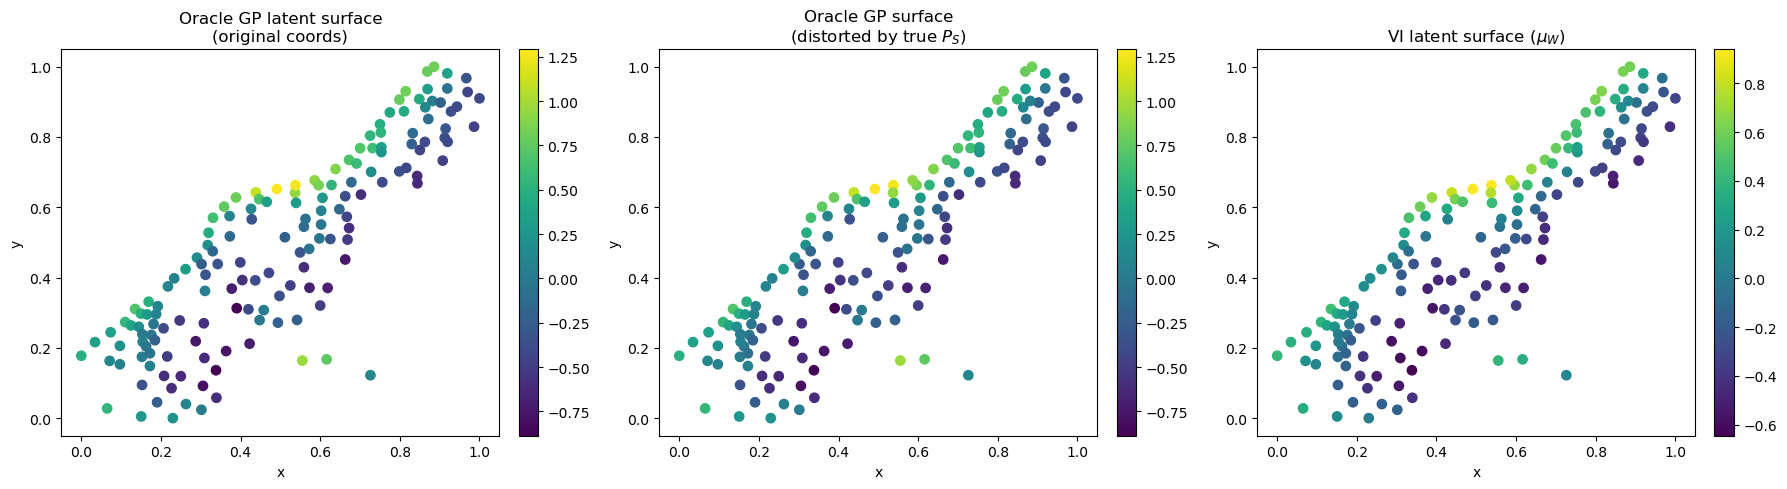

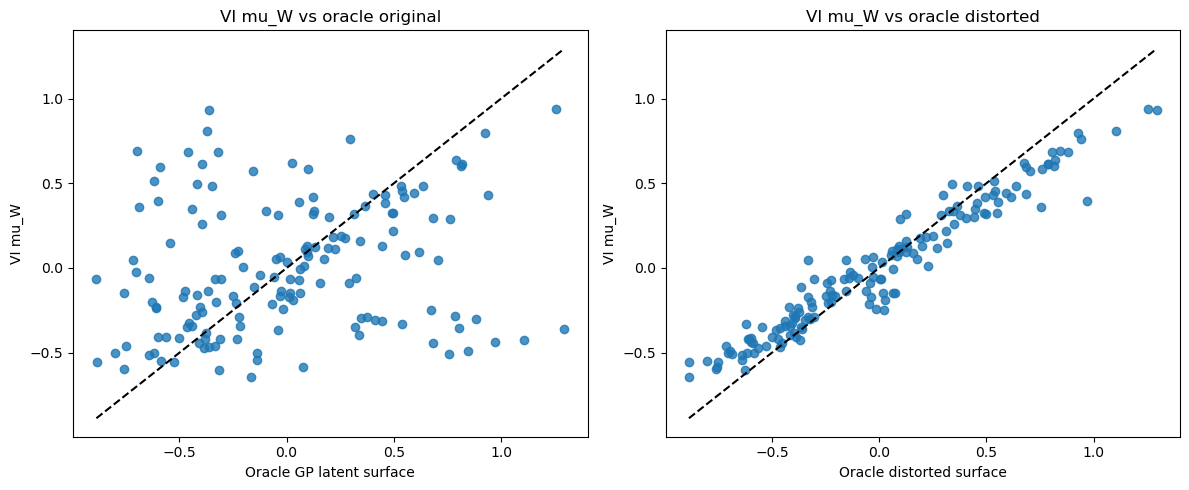

In [25]:
# ============================================================
# STEP 5: Compare latent surfaces
#   - Oracle GP latent surface on original coords
#   - Oracle GP surface distorted by true spatial permutation
#   - VI latent surface mu_W
#
# NOTE:
#   In this real-data notebook, there is no true generative W.
#   So we use the oracle GP posterior mean on original data
#   as the "reference truth".
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helper 1: block-diagonal spatial permutation matrix
# ------------------------------------------------------------
def make_big_block_perm(P_small, n_blocks):
    """
    Build full block-diagonal permutation:
        P_big = I_B \kron P_small
    where P_small is n_i x n_i.
    """
    P_small = P_small.detach().cpu()
    I_B = torch.eye(n_blocks)
    return torch.kron(I_B, P_small).float()

from utils import round_to_perm

# ------------------------------------------------------------
# Helper 2: GP posterior mean of latent W
# Model:
#   Y = X beta + W + eps
#   W ~ N(0, K), eps ~ N(0, tau^2 I)
# posterior mean:
#   E[W|Y] = K (K + tau^2 I)^(-1) (Y - X beta)
# ------------------------------------------------------------
def gp_posterior_mean_w(coords, X, Y, beta, sigmasq, phi, tausq, jitter=1e-6):
    coords = coords.detach().cpu().float()
    X = X.detach().cpu().float()
    Y = Y.detach().cpu().float().view(-1)

    if X.ndim == 1:
        X = X.unsqueeze(1)

    beta = torch.as_tensor(beta, dtype=torch.float32).view(-1)
    resid = Y - (X @ beta).view(-1)

    D = torch.cdist(coords, coords, p=2)
    K = sigmasq * torch.exp(-phi * D)
    C = K + (tausq + jitter) * torch.eye(K.shape[0])

    mu_w = K @ torch.linalg.solve(C, resid)
    return mu_w


# ------------------------------------------------------------
# Helper 3: recursively search a dict/list/tuple for a key
# containing some substring, e.g. "mu_W"
# ------------------------------------------------------------
def recursive_find(obj, target_substr):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if target_substr.lower() in str(k).lower():
                return v
        for _, v in obj.items():
            out = recursive_find(v, target_substr)
            if out is not None:
                return out

    elif isinstance(obj, (list, tuple)):
        for v in obj:
            out = recursive_find(v, target_substr)
            if out is not None:
                return out

    return None


# ------------------------------------------------------------
# Helper 4: convert candidate VI output to a flat vector
# ------------------------------------------------------------
def to_flat_vector(x, n_expected=None):
    if x is None:
        return None

    if isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    else:
        arr = np.asarray(x)

    arr = np.squeeze(arr)

    # common case: (B, n_i)
    if arr.ndim == 2:
        arr = arr.reshape(-1)

    if n_expected is not None and arr.size != n_expected:
        print(f"[warn] extracted object has length {arr.size}, expected {n_expected}")

    return arr


# ------------------------------------------------------------
# 1) Oracle latent surface on original coordinates
# ------------------------------------------------------------
w_oracle = gp_posterior_mean_w(
    coords=coords_orig,
    X=X_orig,
    Y=Y_orig,
    beta=oracle_params["beta"],
    sigmasq=oracle_params["sigmasq"],
    phi=oracle_params["phi"],
    tausq=oracle_params["tausq"],
)

# ------------------------------------------------------------
# 2) Distort oracle surface with the TRUE spatial permutation
#    used to generate coords_perm from coords_orig
# ------------------------------------------------------------
P_S_big = make_big_block_perm(perm_matrix_s, n_blocks=31)
w_oracle_distorted = (P_S_big @ w_oracle.detach().cpu()).numpy()
w_oracle = w_oracle.detach().cpu().numpy()

# ------------------------------------------------------------
# 3) Extract VI mu_W
#    This tries to find anything named like "mu_W" in vi_results
# ------------------------------------------------------------
mu_W_raw = recursive_find(vi_results, "mu_W")
mu_W_vi = to_flat_vector(mu_W_raw, n_expected=len(w_oracle))

if mu_W_vi is None:
    raise ValueError(
        "Could not find `mu_W` inside `vi_results`. "
        "Run `vi_results.keys()` and inspect the nested structure."
    )

print("Extracted VI mu_W shape:", mu_W_vi.shape)


# ------------------------------------------------------------
# 4) Optional: try to extract estimated spatial permutation
#    from VI output if available
# ------------------------------------------------------------

piS_est = round_to_perm(vi_results['results']['M_X_star']) # default to true perm if not found in VI output
# ------------------------------------------------------------
# 5) If VI mu_W is already in original latent ordering, compare to w_oracle.
#    If VI mu_W is still in permuted/distorted ordering, compare to w_oracle_distorted.
#
#    Since implementation details may differ, we report BOTH.
# ------------------------------------------------------------
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def corr(a, b):
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

print("\n--- Surface comparison metrics ---")
print("VI mu_W  vs oracle original:")
print("  RMSE =", rmse(mu_W_vi, w_oracle))
print("  Corr =", corr(mu_W_vi, w_oracle))

print("VI mu_W  vs oracle distorted:")
print("  RMSE =", rmse(mu_W_vi, w_oracle_distorted))
print("  Corr =", corr(mu_W_vi, w_oracle_distorted))


# ------------------------------------------------------------
# 6) Visualization
#   Panel A: oracle latent surface on original coords
#   Panel B: oracle surface after true spatial distortion on coords_perm
#   Panel C: VI mu_W on coords_perm
#
# If your VI mu_W is actually on original ordering, replace coords_perm by coords_orig.
# ------------------------------------------------------------
coords_orig_np = coords_orig.detach().cpu().numpy()
coords_perm_np = coords_perm.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Oracle/original
sc0 = axes[0].scatter(
    coords_orig_np[:, 0], coords_orig_np[:, 1],
    c=w_oracle, s=45
)
axes[0].set_title("Oracle GP latent surface\n(original coords)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04)

# Oracle distorted by TRUE spatial permutation
sc1 = axes[1].scatter(
    coords_perm_np[:, 0], coords_perm_np[:, 1],
    c=w_oracle_distorted, s=45
)
axes[1].set_title("Oracle GP surface\n(distorted by true $P_S$)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(sc1, ax=axes[1], fraction=0.046, pad=0.04)

# VI mu_W
sc2 = axes[2].scatter(
    coords_perm_np[:, 0], coords_perm_np[:, 1],
    c=mu_W_vi, s=45
)
axes[2].set_title("VI latent surface ($\\mu_W$)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(sc2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7) Scatter comparisons
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(w_oracle, mu_W_vi, alpha=0.8)
mn = min(w_oracle.min(), mu_W_vi.min())
mx = max(w_oracle.max(), mu_W_vi.max())
axes[0].plot([mn, mx], [mn, mx], 'k--')
axes[0].set_title("VI mu_W vs oracle original")
axes[0].set_xlabel("Oracle GP latent surface")
axes[0].set_ylabel("VI mu_W")

axes[1].scatter(w_oracle_distorted, mu_W_vi, alpha=0.8)
mn = min(w_oracle_distorted.min(), mu_W_vi.min())
mx = max(w_oracle_distorted.max(), mu_W_vi.max())
axes[1].plot([mn, mx], [mn, mx], 'k--')
axes[1].set_title("VI mu_W vs oracle distorted")
axes[1].set_xlabel("Oracle distorted surface")
axes[1].set_ylabel("VI mu_W")

plt.tight_layout()
plt.show()

In [ ]:
from utils import round_to_perm
Mhat = 
round_to_perm(Mhat)

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])